Image size : 672 rows × 895 cols × 426 bands
Expected size : 672 rows × 895 cols

Total valid samples: 466

Pixel count per class:
bare            : 50
built-up        : 48
cropland        : 50
grassland       : 48
greenhouse      : 112
paddy-field     : 50
solar-panel     : 62
water           : 46


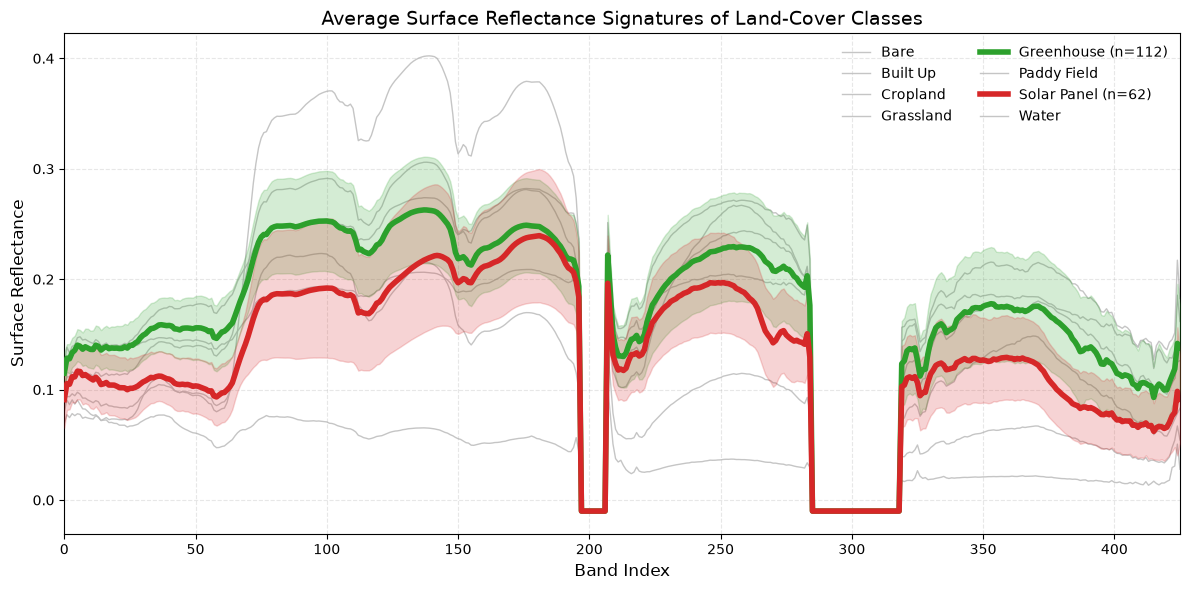

In [10]:
# =============================================================================
# TANAGER HYPERSPECTRAL: SURFACE REFLECTANCE ANALYSIS
# =============================================================================

from pathlib import Path
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import h5py
from affine import Affine
from rasterio.features import rasterize

# ==========================================================
# CONFIGURATION
# ==========================================================
HDF5_FILE = Path("/Volumes/Backup/UNIVERSITY_OF_TSUKUBA/WUN RDF 2026/20250503_020525_16_4001_ortho_sr_hdf5.h5")
POLY_FOLDER = Path(".")

CLASSES = [
    "bare",
    "built-up",
    "cropland",
    "grassland",
    "greenhouse",
    "paddy-field",
    "solar-panel",
    "water"
]

class_to_id = {c: i + 1 for i, c in enumerate(CLASSES)}

# ==========================================================
# LOAD AVIRIS-NG DATA
# ==========================================================
with h5py.File(HDF5_FILE, "r") as f:

    cube = f["HDFEOS"]["GRIDS"]["HYP"]["Data Fields"]["surface_reflectance"][:]
    cube = np.moveaxis(cube, 0, -1)

    cloud = f["HDFEOS"]["GRIDS"]["HYP"]["Data Fields"]["beta_cloud_mask"][:]
    cirrus = f["HDFEOS"]["GRIDS"]["HYP"]["Data Fields"]["beta_cirrus_mask"][:]
    nodata = f["HDFEOS"]["GRIDS"]["HYP"]["Data Fields"]["nodata_pixels"][:]

rows, cols, bands = cube.shape

print(f"Image size : {rows} rows × {cols} cols × {bands} bands")

# ==========================================================
# IMAGE GEOREFERENCE
# ==========================================================
upper_left_x = 666390.0
upper_left_y = 3870480.0
lower_right_x = 693240.0
lower_right_y = 3850320.0
pixel_size = 30.0

expected_cols = int((lower_right_x - upper_left_x) / pixel_size)
expected_rows = int((upper_left_y - lower_right_y) / pixel_size)

print(f"Expected size : {expected_rows} rows × {expected_cols} cols")

assert rows == expected_rows, "Row mismatch!"
assert cols == expected_cols, "Column mismatch!"

transform = Affine(
    pixel_size, 0, upper_left_x,
    0, -pixel_size, upper_left_y
)

# ==========================================================
# VALID PIXELS
# ==========================================================
valid_mask = (cloud == 0) & (cirrus == 0) & (nodata == 0)

# ==========================================================
# LOAD POLYGONS
# ==========================================================
label_map = np.zeros((rows, cols), dtype=np.uint8)

for cls in CLASSES:

    shp = POLY_FOLDER / f"{cls}.geojson"

    if not shp.exists():
        print(f"Missing: {shp}")
        continue

    gdf = gpd.read_file(shp).to_crs("EPSG:32653")

    shapes = [
        (geom, class_to_id[cls])
        for geom in gdf.geometry
        if geom is not None and not geom.is_empty
    ]

    if len(shapes) == 0:
        continue

    raster = rasterize(
        shapes=shapes,
        out_shape=(rows, cols),
        transform=transform,
        fill=0,
        dtype=np.uint8
    )

    label_map = np.maximum(label_map, raster)

# ==========================================================
# EXTRACT TRAINING PIXELS
# ==========================================================
X = cube.reshape(-1, bands)
labels = label_map.ravel()
valid = valid_mask.ravel()

mask = (labels > 0) & valid

X = X[mask]
y = labels[mask]

print(f"\nTotal valid samples: {len(y):,}")

# ==========================================================
# COMPUTE MEAN SPECTRA
# ==========================================================
spectra = {}

for cls, cid in class_to_id.items():

    Xc = X[y == cid]

    if len(Xc) == 0:
        print(f"Warning: {cls} has no pixels.")
        continue

    spectra[cls] = {
        "mean": Xc.mean(axis=0),
        "std": Xc.std(axis=0),
        "n": len(Xc)
    }

print("\nPixel count per class:")
for cls, s in spectra.items():
    print(f"{cls:<15} : {s['n']}")

# ==========================================================
# PLOT (Highlight Solar Panel & Greenhouse)
# ==========================================================
plt.figure(figsize=(12, 6))

x = np.arange(bands)

highlight = {
    "solar-panel": {
        "color": "#d62728",
        "linewidth": 4.0,
        "alpha": 1.0
    },
    "greenhouse": {
        "color": "#2ca02c",
        "linewidth": 4.0,
        "alpha": 1.0
    }
}

for cls, s in spectra.items():

    mean = s["mean"]
    std = s["std"]

    if cls in highlight:

        style = highlight[cls]

        plt.plot(
            x,
            mean,
            color=style["color"],
            linewidth=style["linewidth"],
            label=f"{cls.replace('-', ' ').title()} (n={s['n']})",
            zorder=10
        )

        plt.fill_between(
            x,
            mean - std,
            mean + std,
            color=style["color"],
            alpha=0.20,
            zorder=9
        )

    else:

        plt.plot(
            x,
            mean,
            color="0.75",
            linewidth=1.0,
            alpha=0.9,
            label=cls.replace("-", " ").title(),
            zorder=1
        )

plt.xlabel("Band Index", fontsize=12)
plt.ylabel("Surface Reflectance", fontsize=12)
plt.title("Average Surface Reflectance Signatures of Land-Cover Classes", fontsize=14)

plt.xlim(0, bands - 1)

plt.grid(True, linestyle="--", alpha=0.3)

plt.legend(
    frameon=False,
    fontsize=10,
    ncol=2
)

plt.tight_layout()

plt.savefig(
    "spectral_signatures_highlighted.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

Cube shape: (672, 895, 426)
Transform:
| 30.00, 0.00, 666390.00|
| 0.00,-30.00, 3870480.00|
| 0.00, 0.00, 1.00|
Extent: X = [666390.0, 693240.0]
        Y = [3850320.0, 3870480.0]
Accuracy: 0.7595640569395018
              precision    recall  f1-score   support

           1       0.55      0.38      0.45      6266
           2       0.87      0.75      0.81     35826
           3       0.51      0.36      0.42      5698
           4       0.38      0.13      0.20       564
           5       0.81      0.68      0.74     10189
           6       0.66      0.49      0.56       738
           7       0.72      0.99      0.84     32983
           8       0.52      0.23      0.32      2152

    accuracy                           0.76     94416
   macro avg       0.63      0.50      0.54     94416
weighted avg       0.76      0.76      0.75     94416



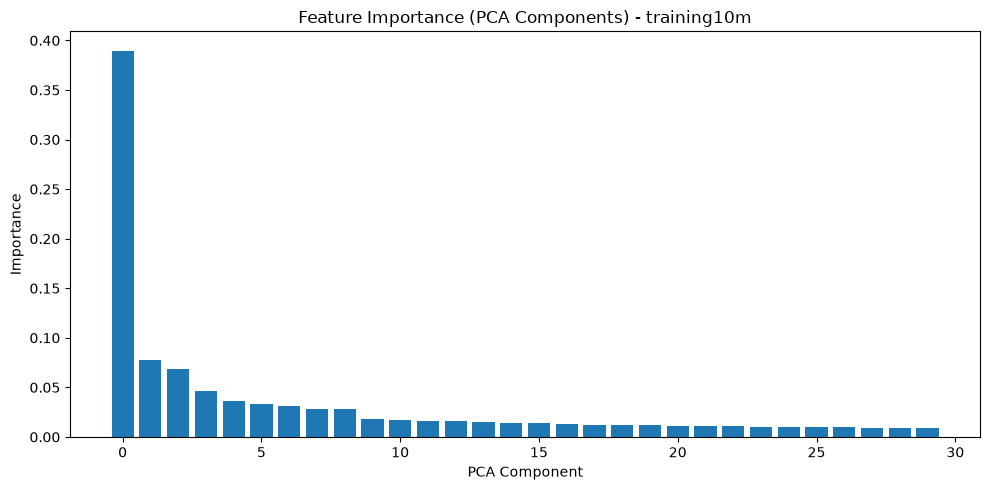

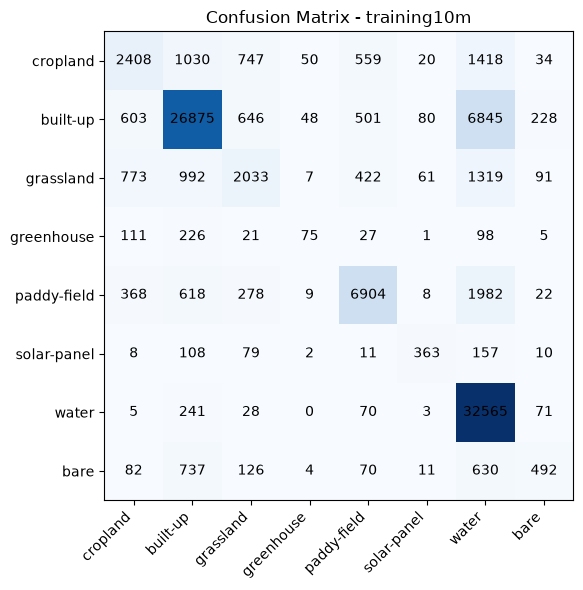

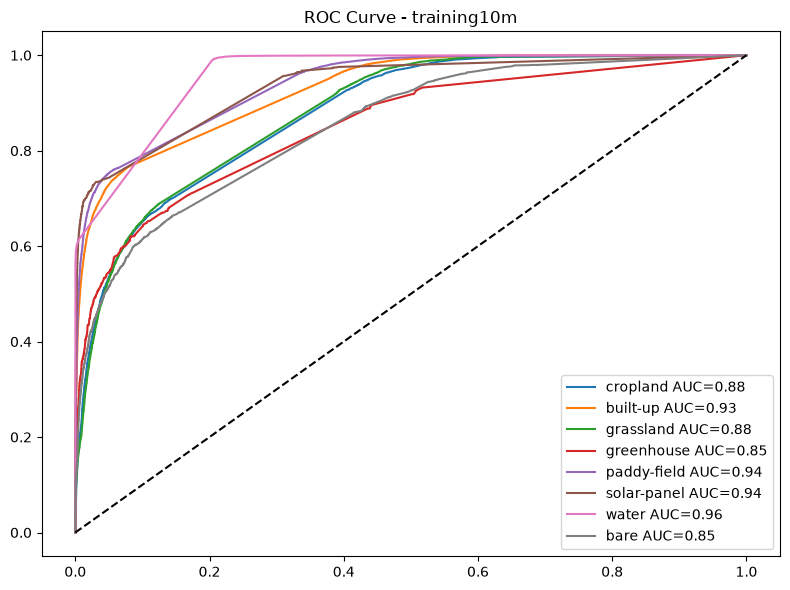

Saved GeoTIFF: final_landuse_map_epsg32653_training10m.tif
Saved: majority_map_training10m.tif morph_map_training10m.tif


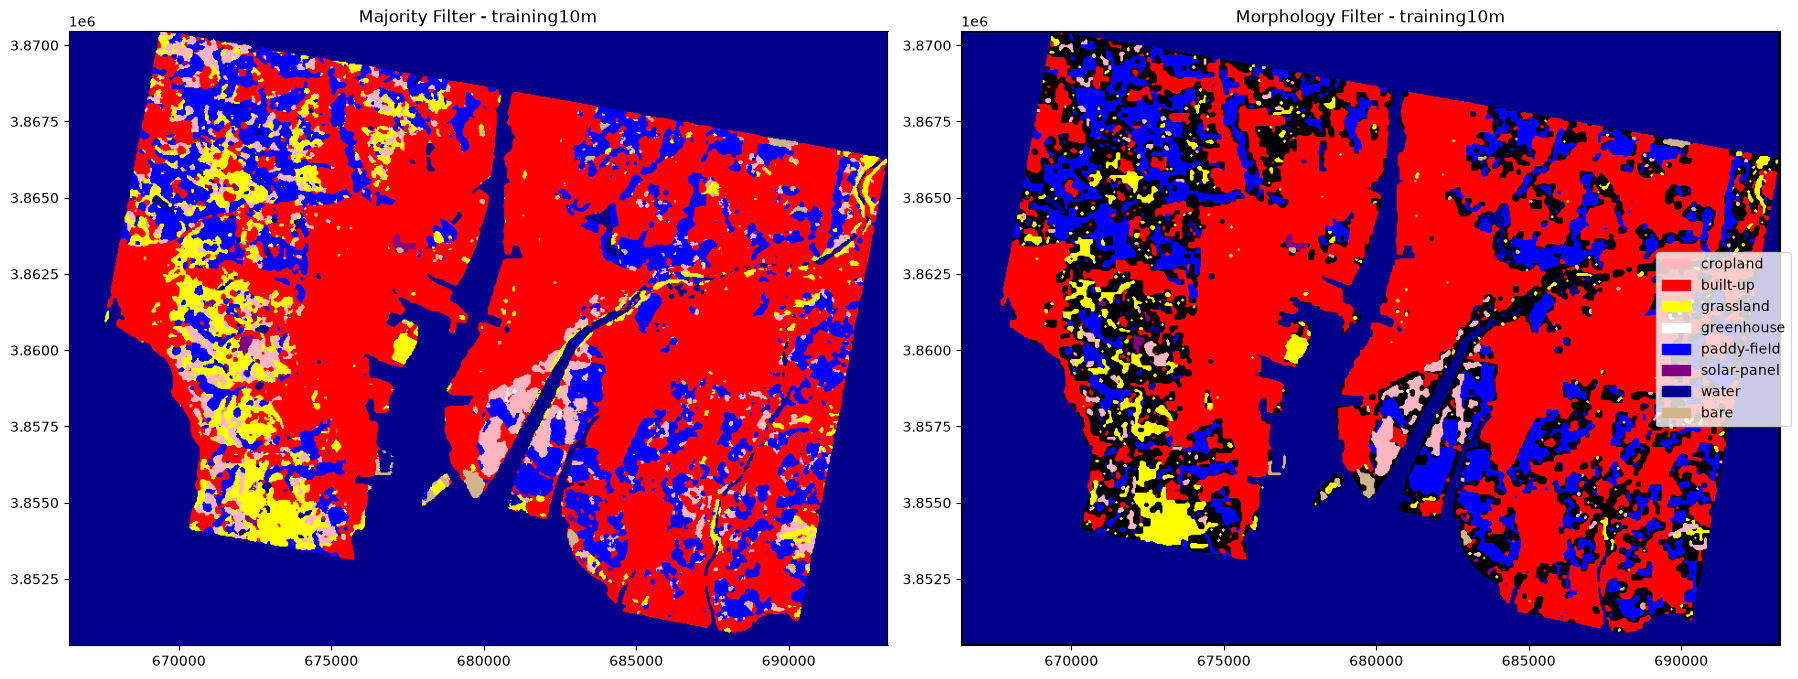

In [12]:
# =============================================================================
# TANAGER HYPERSPECTRAL CLASSIFICATION: USING 10M TRAINING DATASETS
# =============================================================================

import numpy as np
import h5py
import geopandas as gpd
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

import rasterio
from rasterio.features import rasterize
from rasterio.transform import Affine
from rasterio.crs import CRS

from scipy.ndimage import generic_filter, binary_opening, binary_closing

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_curve, auc
)

# =============================================================================
# CONFIG
# =============================================================================

DATA_PATH = r"/Volumes/Backup/UNIVERSITY_OF_TSUKUBA/WUN RDF 2026/20250503_020525_16_4001_ortho_sr_hdf5.h5"
POLY_FOLDER = Path(r"/Volumes/Backup/UNIVERSITY_OF_TSUKUBA/WUN RDF 2026")

CLASSES = [
    "cropland_only","built-up_only","grassland_only","greenhouse_only",
    "paddy-field_only","solar-panel_only","water_only","bare_only"
]

class_to_id = {c: i + 1 for i, c in enumerate(CLASSES)}
id_to_class = {v: k for k, v in class_to_id.items()}

def clean(c):
    return c.replace("_only", "")

color_map = {
    "cropland": "#FFB6C1",
    "built-up": "#FF0000",
    "grassland": "#FFFF00",
    "greenhouse": "#FFFFFF",
    "paddy-field": "#0000FF",
    "solar-panel": "#800080",
    "water": "#00008B",
    "bare": "#D2B48C"
}

# =============================================================================
# LOAD DATA
# =============================================================================

with h5py.File(DATA_PATH, "r") as f:

    cube = f["HDFEOS"]["GRIDS"]["HYP"]["Data Fields"]["surface_reflectance"][:]

    # Convert from (bands, rows, cols) -> (rows, cols, bands)
    cube = np.moveaxis(cube, 0, -1)

h, w, b = cube.shape

print(f"Cube shape: {cube.shape}")

X_full = cube.reshape(-1, b)

# =============================================================================
# LABELS
# =============================================================================

gdfs = {}
for cls in CLASSES:
    gdfs[cls] = gpd.read_file(POLY_FOLDER / f"{cls}.geojson").to_crs("EPSG:32653")

# =============================================================================
# IMAGE GEOREFERENCE (EPSG:32653)
# Metadata:
# UpperLeftPointMtrs = (666390.00, 3870480.00)
# LowerRightMtrs = (693240.00, 3850320.00)
# =============================================================================

min_x = 666390.0
max_x = 693240.0
min_y = 3850320.0
max_y = 3870480.0

pixel_size = 30.0

# Verify image dimensions from metadata
expected_cols = int((max_x - min_x) / pixel_size)
expected_rows = int((max_y - min_y) / pixel_size)

assert w == expected_cols, f"Expected {expected_cols} columns, got {w}"
assert h == expected_rows, f"Expected {expected_rows} rows, got {h}"

# Affine transform
transform = Affine(
    pixel_size, 0.0, min_x,
    0.0, -pixel_size, max_y
)

print("Transform:")
print(transform)
print(f"Extent: X = [{min_x:.1f}, {max_x:.1f}]")
print(f"        Y = [{min_y:.1f}, {max_y:.1f}]")

label_map = np.zeros((h, w), dtype=np.uint8)

for cls, gdf in gdfs.items():
    shapes = [(geom, class_to_id[cls]) for geom in gdf.geometry]
    mask = rasterize(shapes, out_shape=(h, w), transform=transform, fill=0, dtype=np.uint8)
    label_map = np.maximum(label_map, mask)

y_full = label_map.reshape(-1)
mask = y_full > 0

X = X_full[mask]
y = y_full[mask]

# =============================================================================
# TRAIN PIPELINE
# =============================================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=30)
X_pca = pca.fit_transform(X_scaled)

X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.3, random_state=42, stratify=y
)

rf = RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

# =============================================================================
# FEATURE IMPORTANCE PLOT
# =============================================================================

importances = rf.feature_importances_
idx = np.argsort(importances)[::-1]

plt.figure(figsize=(10,5))
plt.bar(range(len(importances)), importances[idx])
plt.title("Feature Importance (PCA Components) - training10m")
plt.xlabel("PCA Component")
plt.ylabel("Importance")
plt.tight_layout()
plt.savefig("feature_importance_training10m.png", dpi=600)
plt.show()

# =============================================================================
# CONFUSION MATRIX PLOT
# =============================================================================

cm = confusion_matrix(y_test, pred)

labels = [clean(id_to_class[i]) for i in sorted(id_to_class.keys())]

plt.figure(figsize=(8,6))
plt.imshow(cm, cmap="Blues")
plt.xticks(np.arange(len(labels)), labels, rotation=45, ha="right")
plt.yticks(np.arange(len(labels)), labels)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.title("Confusion Matrix - training10m")
plt.tight_layout()
plt.savefig("confusion_matrix_training10m.png", dpi=600)
plt.show()

# =============================================================================
# ROC CURVE (MULTICLASS)
# =============================================================================

y_test_bin = label_binarize(y_test, classes=np.unique(y))
y_score = rf.predict_proba(X_test)

plt.figure(figsize=(8,6))

for i in range(y_test_bin.shape[1]):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{clean(id_to_class[i+1])} AUC={roc_auc:.2f}")

plt.plot([0,1],[0,1],"k--")
plt.title("ROC Curve - training10m")
plt.legend()
plt.tight_layout()
plt.savefig("roc_curve_training10m.png", dpi=600)
plt.show()

# =============================================================================
# FULL MAP PREDICTION
# =============================================================================

X_map = scaler.transform(X_full)
X_map = pca.transform(X_map)
pred_map = rf.predict(X_map).reshape(h, w)

# =============================================================================
# MORPHOLOGY
# =============================================================================

def majority_filter(img, size=5):
    def fn(x):
        vals, counts = np.unique(x, return_counts=True)
        return vals[np.argmax(counts)]
    return generic_filter(img, fn, size=size)

pred_majority = majority_filter(pred_map, size=5)

clean_map = np.zeros_like(pred_map)

for cls_id in np.unique(pred_map):
    if cls_id == 0:
        continue
    m = (pred_map == cls_id)
    m = binary_opening(m, structure=np.ones((3,3)))
    m = binary_closing(m, structure=np.ones((5,5)))
    clean_map[m] = cls_id

pred_morph = majority_filter(clean_map, size=3)

# =============================================================================
# GEOREFERENCED EXPORT (EPSG:32653)
# =============================================================================

import rasterio
from rasterio.crs import CRS
from rasterio.transform import Affine

out_path = "final_landuse_map_epsg32653_training10m.tif"

crs = CRS.from_epsg(32653)

with rasterio.open(
    out_path,
    "w",
    driver="GTiff",
    height=h,
    width=w,
    count=1,
    dtype=pred_morph.dtype,
    crs=crs,
    transform=transform,
) as dst:
    dst.write(pred_morph, 1)

print("Saved GeoTIFF:", out_path)

# =============================================================================
# COLOR MAP
# =============================================================================

lut = np.zeros((len(CLASSES)+1, 3), dtype=float)

for cls, idx in class_to_id.items():
    lut[idx] = mcolors.to_rgb(color_map[clean(cls)])

def to_rgb(img):
    return lut[img]

rgb_majority = to_rgb(pred_majority)
rgb_morph = to_rgb(pred_morph)

# =============================================================================
# GEOEXPORT EPSG:32653
# =============================================================================

crs = CRS.from_epsg(32653)

out1 = "majority_map_training10m.tif"
out2 = "morph_map_training10m.tif"

with rasterio.open(out1, "w", driver="GTiff",
                   height=h, width=w, count=1,
                   dtype=pred_majority.dtype,
                   crs=crs, transform=transform) as dst:
    dst.write(pred_majority, 1)

with rasterio.open(out2, "w", driver="GTiff",
                   height=h, width=w, count=1,
                   dtype=pred_morph.dtype,
                   crs=crs, transform=transform) as dst:
    dst.write(pred_morph, 1)

print("Saved:", out1, out2)

# =============================================================================
# PLOT FINAL MAPS
# =============================================================================

left = transform.c
top = transform.f
right = left + w * transform.a
bottom = top + h * transform.e
extent = [left, right, bottom, top]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

axes[0].imshow(rgb_majority, extent=extent)
axes[0].set_title("Majority Filter - training10m")

axes[1].imshow(rgb_morph, extent=extent)
axes[1].set_title("Morphology Filter - training10m")

legend = [mpatches.Patch(color=color_map[clean(c)], label=clean(c)) for c in CLASSES]
fig.legend(handles=legend, loc="center right")

plt.tight_layout()
plt.savefig("final_map_comparison_training10m.png", dpi=600)
plt.show()

Cube shape: (672, 895, 426)
Transform:
| 30.00, 0.00, 666390.00|
| 0.00,-30.00, 3870480.00|
| 0.00, 0.00, 1.00|
Extent: X = [666390.0, 693240.0]
        Y = [3850320.0, 3870480.0]
Accuracy: 0.7783586485463037
              precision    recall  f1-score   support

           1       0.61      0.45      0.52      6118
           2       0.89      0.76      0.82     37294
           3       0.59      0.37      0.46      4842
           4       0.50      0.21      0.30       411
           5       0.81      0.68      0.74     10842
           6       0.72      0.50      0.59       717
           7       0.73      0.98      0.84     33162
           8       0.64      0.31      0.42      1682

    accuracy                           0.78     95068
   macro avg       0.69      0.53      0.59     95068
weighted avg       0.78      0.78      0.77     95068



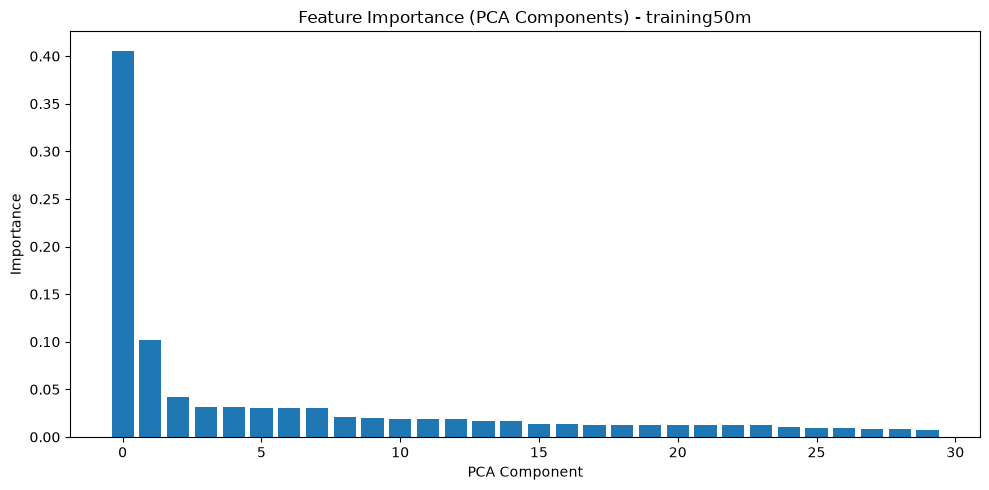

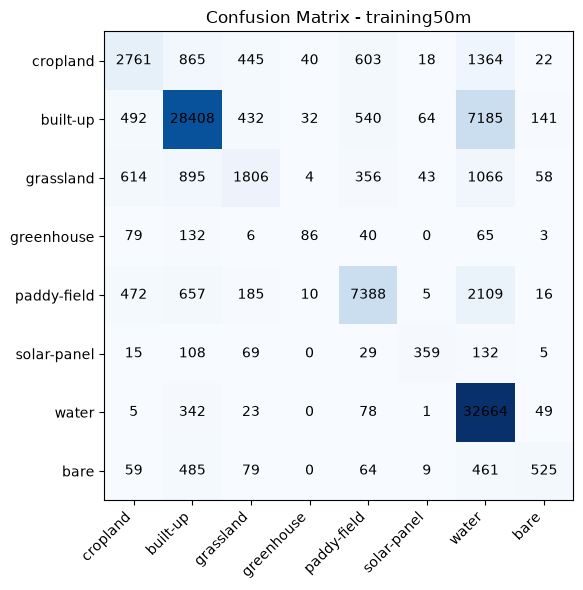

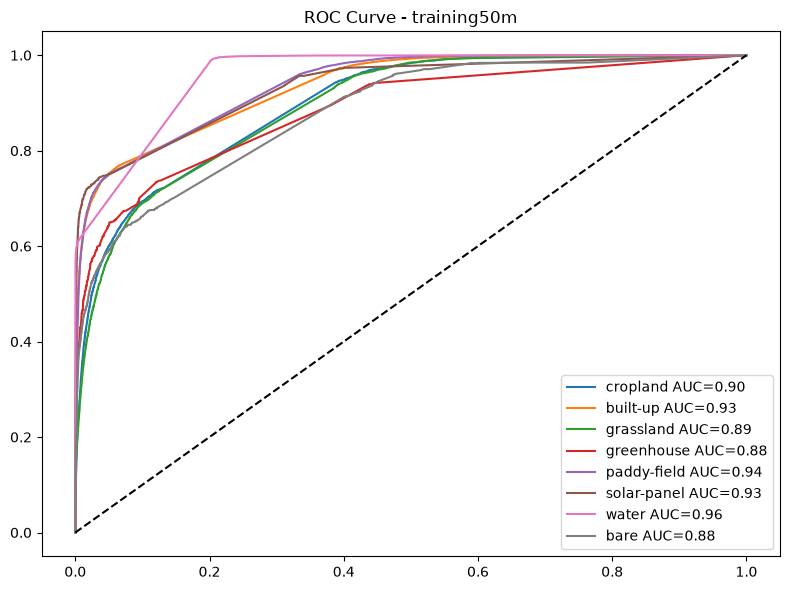

Saved GeoTIFF: final_landuse_map_epsg32653_training50m.tif
Saved: majority_map_training50m.tif morph_map_training50m.tif


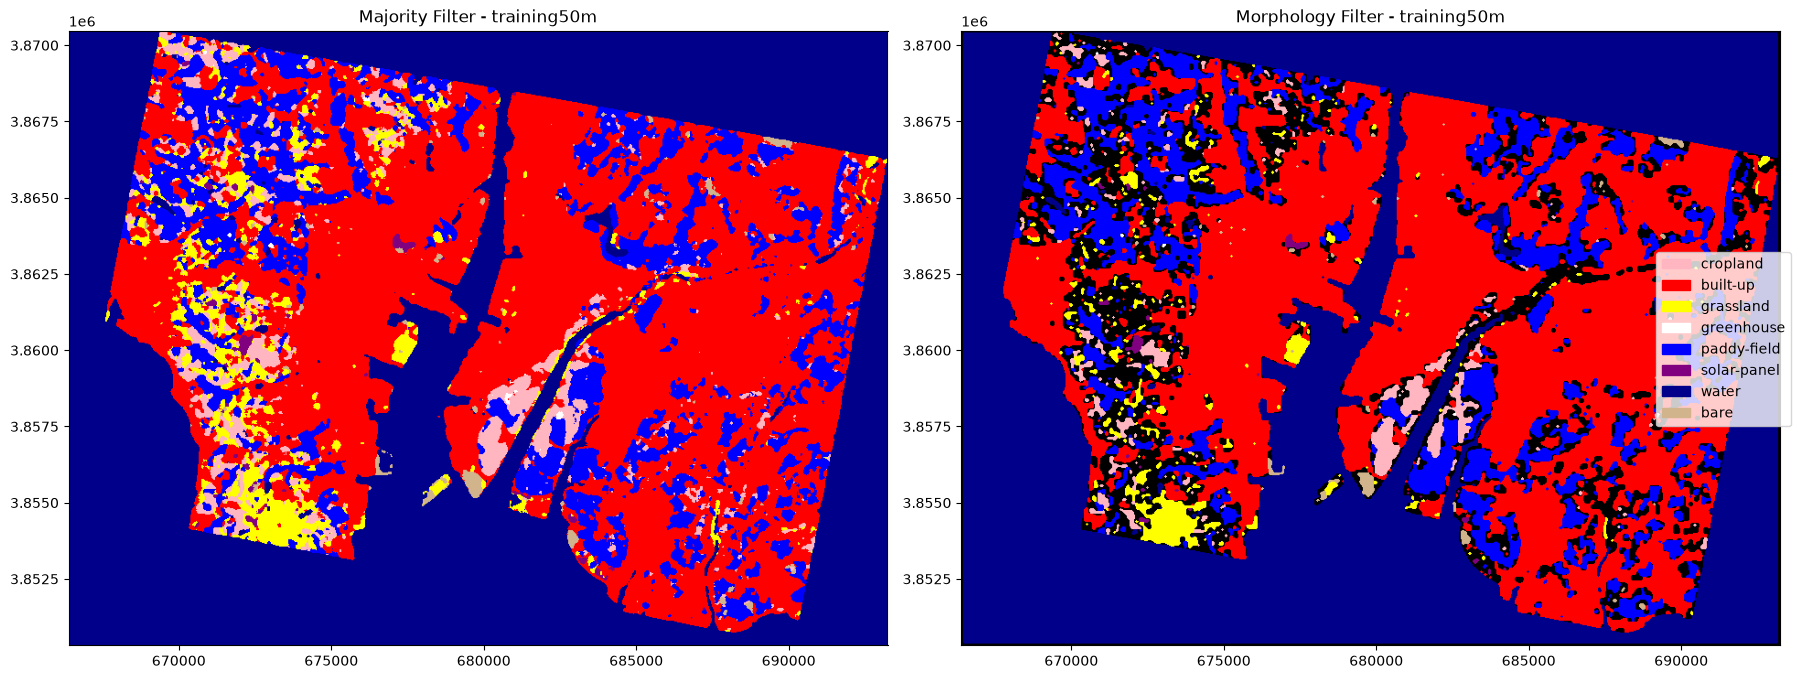

In [13]:
# =============================================================================
# TANAGER HYPERSPECTRAL CLASSIFICATION: USING 50M TRAINING DATASETS
# =============================================================================

import numpy as np
import h5py
import geopandas as gpd
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

import rasterio
from rasterio.features import rasterize
from rasterio.transform import Affine
from rasterio.crs import CRS

from scipy.ndimage import generic_filter, binary_opening, binary_closing

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_curve, auc
)

# =============================================================================
# CONFIG
# =============================================================================

DATA_PATH = r"/Volumes/Backup/UNIVERSITY_OF_TSUKUBA/WUN RDF 2026/20250503_020525_16_4001_ortho_sr_hdf5.h5"
POLY_FOLDER = Path(r"/Volumes/Backup/UNIVERSITY_OF_TSUKUBA/WUN RDF 2026/training_50m")

CLASSES = [
    "cropland","built-up","grassland","greenhouse",
    "paddy-field","solar-panel","water","bare"
]

class_to_id = {c: i + 1 for i, c in enumerate(CLASSES)}
id_to_class = {v: k for k, v in class_to_id.items()}

def clean(c):
    return c.replace("_only", "")

color_map = {
    "cropland": "#FFB6C1",
    "built-up": "#FF0000",
    "grassland": "#FFFF00",
    "greenhouse": "#FFFFFF",
    "paddy-field": "#0000FF",
    "solar-panel": "#800080",
    "water": "#00008B",
    "bare": "#D2B48C"
}

# =============================================================================
# LOAD DATA
# =============================================================================

with h5py.File(DATA_PATH, "r") as f:

    cube = f["HDFEOS"]["GRIDS"]["HYP"]["Data Fields"]["surface_reflectance"][:]

    # Convert from (bands, rows, cols) -> (rows, cols, bands)
    cube = np.moveaxis(cube, 0, -1)

h, w, b = cube.shape

print(f"Cube shape: {cube.shape}")

X_full = cube.reshape(-1, b)

# =============================================================================
# LABELS
# =============================================================================

gdfs = {}
for cls in CLASSES:
    gdfs[cls] = gpd.read_file(POLY_FOLDER / f"{cls}.geojson").to_crs("EPSG:32653")

# =============================================================================
# IMAGE GEOREFERENCE (EPSG:32653)
# Metadata:
# UpperLeftPointMtrs = (666390.00, 3870480.00)
# LowerRightMtrs = (693240.00, 3850320.00)
# =============================================================================

min_x = 666390.0
max_x = 693240.0
min_y = 3850320.0
max_y = 3870480.0

pixel_size = 30.0

# Verify image dimensions from metadata
expected_cols = int((max_x - min_x) / pixel_size)
expected_rows = int((max_y - min_y) / pixel_size)

assert w == expected_cols, f"Expected {expected_cols} columns, got {w}"
assert h == expected_rows, f"Expected {expected_rows} rows, got {h}"

# Affine transform
transform = Affine(
    pixel_size, 0.0, min_x,
    0.0, -pixel_size, max_y
)

print("Transform:")
print(transform)
print(f"Extent: X = [{min_x:.1f}, {max_x:.1f}]")
print(f"        Y = [{min_y:.1f}, {max_y:.1f}]")

label_map = np.zeros((h, w), dtype=np.uint8)

for cls, gdf in gdfs.items():
    shapes = [(geom, class_to_id[cls]) for geom in gdf.geometry]
    mask = rasterize(shapes, out_shape=(h, w), transform=transform, fill=0, dtype=np.uint8)
    label_map = np.maximum(label_map, mask)

y_full = label_map.reshape(-1)
mask = y_full > 0

X = X_full[mask]
y = y_full[mask]

# =============================================================================
# TRAIN PIPELINE
# =============================================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=30)
X_pca = pca.fit_transform(X_scaled)

X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.3, random_state=42, stratify=y
)

rf = RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

# =============================================================================
# FEATURE IMPORTANCE PLOT
# =============================================================================

importances = rf.feature_importances_
idx = np.argsort(importances)[::-1]

plt.figure(figsize=(10,5))
plt.bar(range(len(importances)), importances[idx])
plt.title("Feature Importance (PCA Components) - training50m")
plt.xlabel("PCA Component")
plt.ylabel("Importance")
plt.tight_layout()
plt.savefig("feature_importance_training50m.png", dpi=600)
plt.show()

# =============================================================================
# CONFUSION MATRIX PLOT
# =============================================================================

cm = confusion_matrix(y_test, pred)

labels = [clean(id_to_class[i]) for i in sorted(id_to_class.keys())]

plt.figure(figsize=(8,6))
plt.imshow(cm, cmap="Blues")
plt.xticks(np.arange(len(labels)), labels, rotation=45, ha="right")
plt.yticks(np.arange(len(labels)), labels)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.title("Confusion Matrix - training50m")
plt.tight_layout()
plt.savefig("confusion_matrix_training50m.png", dpi=600)
plt.show()

# =============================================================================
# ROC CURVE (MULTICLASS)
# =============================================================================

y_test_bin = label_binarize(y_test, classes=np.unique(y))
y_score = rf.predict_proba(X_test)

plt.figure(figsize=(8,6))

for i in range(y_test_bin.shape[1]):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{clean(id_to_class[i+1])} AUC={roc_auc:.2f}")

plt.plot([0,1],[0,1],"k--")
plt.title("ROC Curve - training50m")
plt.legend()
plt.tight_layout()
plt.savefig("roc_curve_training50m.png", dpi=600)
plt.show()

# =============================================================================
# FULL MAP PREDICTION
# =============================================================================

X_map = scaler.transform(X_full)
X_map = pca.transform(X_map)
pred_map = rf.predict(X_map).reshape(h, w)

# =============================================================================
# MORPHOLOGY
# =============================================================================

def majority_filter(img, size=5):
    def fn(x):
        vals, counts = np.unique(x, return_counts=True)
        return vals[np.argmax(counts)]
    return generic_filter(img, fn, size=size)

pred_majority = majority_filter(pred_map, size=5)

clean_map = np.zeros_like(pred_map)

for cls_id in np.unique(pred_map):
    if cls_id == 0:
        continue
    m = (pred_map == cls_id)
    m = binary_opening(m, structure=np.ones((3,3)))
    m = binary_closing(m, structure=np.ones((5,5)))
    clean_map[m] = cls_id

pred_morph = majority_filter(clean_map, size=3)

# =============================================================================
# GEOREFERENCED EXPORT (EPSG:32653)
# =============================================================================

import rasterio
from rasterio.crs import CRS
from rasterio.transform import Affine

out_path = "final_landuse_map_epsg32653_training50m.tif"

crs = CRS.from_epsg(32653)

with rasterio.open(
    out_path,
    "w",
    driver="GTiff",
    height=h,
    width=w,
    count=1,
    dtype=pred_morph.dtype,
    crs=crs,
    transform=transform,
) as dst:
    dst.write(pred_morph, 1)

print("Saved GeoTIFF:", out_path)

# =============================================================================
# COLOR MAP
# =============================================================================

lut = np.zeros((len(CLASSES)+1, 3), dtype=float)

for cls, idx in class_to_id.items():
    lut[idx] = mcolors.to_rgb(color_map[clean(cls)])

def to_rgb(img):
    return lut[img]

rgb_majority = to_rgb(pred_majority)
rgb_morph = to_rgb(pred_morph)

# =============================================================================
# GEOEXPORT EPSG:32653
# =============================================================================

crs = CRS.from_epsg(32653)

out1 = "majority_map_training50m.tif"
out2 = "morph_map_training50m.tif"

with rasterio.open(out1, "w", driver="GTiff",
                   height=h, width=w, count=1,
                   dtype=pred_majority.dtype,
                   crs=crs, transform=transform) as dst:
    dst.write(pred_majority, 1)

with rasterio.open(out2, "w", driver="GTiff",
                   height=h, width=w, count=1,
                   dtype=pred_morph.dtype,
                   crs=crs, transform=transform) as dst:
    dst.write(pred_morph, 1)

print("Saved:", out1, out2)

# =============================================================================
# PLOT FINAL MAPS
# =============================================================================

left = transform.c
top = transform.f
right = left + w * transform.a
bottom = top + h * transform.e
extent = [left, right, bottom, top]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

axes[0].imshow(rgb_majority, extent=extent)
axes[0].set_title("Majority Filter - training50m")

axes[1].imshow(rgb_morph, extent=extent)
axes[1].set_title("Morphology Filter - training50m")

legend = [mpatches.Patch(color=color_map[clean(c)], label=clean(c)) for c in CLASSES]
fig.legend(handles=legend, loc="center right")

plt.tight_layout()
plt.savefig("final_map_comparison_training50m.png", dpi=600)
plt.show()